# Notebook 2: Exploratory Data Analysis (EDA)

**Goal:** Characterize the full dataset — statistics across subjects/sites, volume sizes, label properties, class imbalance, and vendor variability.

## What we'll cover:
1. Dataset demographics (sites, vendors, subject counts)
2. Volume shape & spacing distributions
3. Intensity statistics per subject/site
4. Label statistics (cord volume, extent, class imbalance)
5. Site-level variability analysis
6. Train/val split visualization

In [1]:
import os
import sys
import re
import json
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("..")
sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = PROJECT_ROOT / "data" / "spine-generic"
LABELS_ROOT = DATA_ROOT / "derivatives" / "labels"

# Use the site extraction logic from our module
from src.data.spine_generic import get_site_from_subject, create_datalist

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print(f"Data root: {DATA_ROOT.resolve()}")

Data root: /home/l091835/cns/data/spine-generic


## 1. Dataset Demographics

The Spine-Generic dataset has 267 subjects from 42 sites across 3 continents, using all 3 major MRI vendors (GE, Philips, Siemens).

In [2]:
# Load participants.tsv (BIDS standard demographics file)
participants_file = DATA_ROOT / "participants.tsv"
if participants_file.exists():
    participants = pd.read_csv(participants_file, sep='\t')
    print(f"Participants file: {len(participants)} rows")
    print(f"\nColumns: {list(participants.columns)}")
    display(participants.head(10))
else:
    print("participants.tsv not found — building from directory structure")
    participants = None

Participants file: 267 rows

Columns: ['participant_id', 'sex', 'age', 'height', 'weight', 'date_of_scan', 'institution_id', 'institution', 'manufacturer', 'manufacturers_model_name', 'receive_coil_name', 'software_versions', 'researcher', 'pathology', 'notes']


,participant_id,sex,age,height,weight,date_of_scan,institution_id,institution,manufacturer,manufacturers_model_name,receive_coil_name,software_versions,researcher,pathology,notes
0,sub-amu01,M,28,176.0,70.0,2019-02-12,amu,AMU - CEMEREM,Siemens,Verio,NeckMatrix,syngo_MR_B17,Virginie Callot,HC,NaN
1,sub-amu02,M,28,183.0,67.0,2019-02-13,amu,AMU - CEMEREM,Siemens,Verio,NeckMatrix,syngo_MR_B17,Virginie Callot,HC,"disc protrusion Th2/3, visualised central canal"
2,sub-amu03,F,28,163.0,76.0,2019-02-13,amu,AMU - CEMEREM,Siemens,Verio,NeckMatrix,syngo_MR_B17,Virginie Callot,HC,disc protrusion C3/4 and C5/6
3,sub-amu04,F,44,163.0,55.0,2019-03-01,amu,AMU - CEMEREM,Siemens,Verio,NeckMatrix,syngo_MR_B17,Virginie Callot,HC,disc protrusion C6/7
4,sub-amu05,F,39,175.0,66.0,2019-03-01,amu,AMU - CEMEREM,Siemens,Verio,NeckMatrix,syngo_MR_B17,Virginie Callot,HC,disc protrusion C4/5/6 and mild kyphosis
5,sub-balgrist01,F,31,158.0,60.0,NaN,balgrist,Spinal Cord Injury Center University Balgrist ...,Siemens,Prisma,HeadNeck_64,VE11C,"M. Seif, P. Freund",HC,Mild kyphosis
6,sub-balgrist02,F,22,170.0,72.0,NaN,balgrist,Spinal Cord Injury Center University Balgrist ...,Siemens,Prisma,HeadNeck_64,VE11C,"M. Seif, P. Freund",HC,Mild kyphosis
7,sub-balgrist03,F,23,175.0,85.0,NaN,balgrist,Spinal Cord Injury Center University Balgrist ...,Siemens,Prisma,HeadNeck_64,VE11C,"M. Seif, P. Freund",HC,disc protrusion C3/4 and mild kyphosis
8,sub-balgrist04,M,28,195.0,90.0,NaN,balgrist,Spinal Cord Injury Center University Balgrist ...,Siemens,Prisma,HeadNeck_64,VE11C,"M. Seif, P. Freund",HC,NaN
9,sub-balgrist05,M,27,168.0,60.0,NaN,balgrist,Spinal Cord Injury Center University Balgrist ...,Siemens,Prisma,HeadNeck_64,VE11C,"M. Seif, P. Freund",HC,disc protrusion C4-7


In [3]:
# Extract sites from all subjects
subject_dirs = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir() and d.name.startswith("sub-")])

site_data = []
for sub_id in subject_dirs:
    try:
        site = get_site_from_subject(sub_id)
    except ValueError:
        site = "unknown"
    site_data.append({"subject": sub_id, "site": site})

df_subjects = pd.DataFrame(site_data)
site_counts = df_subjects['site'].value_counts()

print(f"Total subjects: {len(df_subjects)}")
print(f"Unique sites:   {df_subjects['site'].nunique()}")
print(f"\nSubjects per site:")
print(site_counts.to_string())

Total subjects: 267
Unique sites:   43

Subjects per site:
site
unknown          13
oxfordFmrib      11
mniS              9
brnoUhb           8
sherbrooke        7
ucdavis           7
tokyoSkyra        7
milan             7
tokyoIngenia      7
cmrrb             7
vallHebron        7
unf               7
tehranS           6
stanford          6
nottwil           6
cardiff           6
brnoCeitec        6
barcelona         6
cmrra             6
balgrist          6
strasbourg        6
nwu               6
mgh               6
hamburg           6
geneva            6
fslAchieva        6
fslPrisma         6
ucl               6
ubc               6
vuiisAchieva      6
queensland        6
mountSinai        6
mpicbs            6
perform           6
pavia             6
vuiisIngenia      6
oxfordOhba        5
beijingPrisma     5
amu               5
beijingGE         4
beijingVerio      4
dresden           2
mniPilot          1


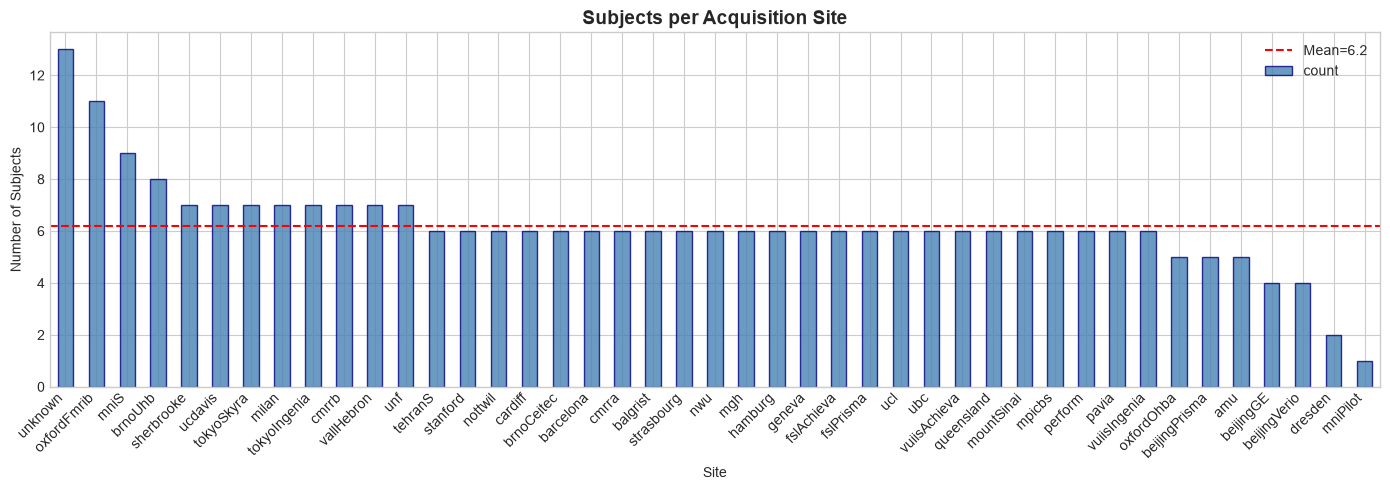

In [4]:
# Visualize subjects per site
fig, ax = plt.subplots(figsize=(14, 5))
site_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='navy', alpha=0.8)
ax.set_title('Subjects per Acquisition Site', fontsize=14, fontweight='bold')
ax.set_xlabel('Site')
ax.set_ylabel('Number of Subjects')
ax.axhline(y=site_counts.mean(), color='red', linestyle='--', label=f'Mean={site_counts.mean():.1f}')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. Volume Shape & Spacing Distributions

Different scanners produce different matrix sizes and resolutions. We need to understand this variability to choose appropriate resampling parameters.

In [5]:
# Scan all subjects — collect shape and spacing info
# (This only reads NIfTI headers, not full data — fast!)

volume_info = []

for sub_dir in sorted(DATA_ROOT.iterdir()):
    if not sub_dir.is_dir() or not sub_dir.name.startswith("sub-"):
        continue
    sub_id = sub_dir.name
    img_path = sub_dir / "anat" / f"{sub_id}_T2w.nii.gz"
    
    if not img_path.exists() or img_path.stat().st_size < 1000:
        continue
    
    try:
        site = get_site_from_subject(sub_id)
    except ValueError:
        site = "unknown"
    
    # Read header only (fast — doesn't load the data)
    try:
        img = nib.load(str(img_path))
        shape = img.shape
        zooms = img.header.get_zooms()[:3]
        orient = nib.aff2axcodes(img.affine)
        
        volume_info.append({
            "subject": sub_id,
            "site": site,
            "shape_x": shape[0],
            "shape_y": shape[1],
            "shape_z": shape[2],
            "spacing_x": zooms[0],
            "spacing_y": zooms[1],
            "spacing_z": zooms[2],
            "orientation": ''.join(orient),
            "file_size_mb": img_path.stat().st_size / 1e6,
        })
    except Exception as e:
        print(f"  Error reading {sub_id}: {e}")

df_vol = pd.DataFrame(volume_info)
print(f"Scanned {len(df_vol)} subjects with real image data")
print(f"\nShape statistics:")
display(df_vol[['shape_x', 'shape_y', 'shape_z', 'spacing_x', 'spacing_y', 'spacing_z']].describe())

Scanned 267 subjects with real image data

Shape statistics:


,shape_x,shape_y,shape_z,spacing_x,spacing_y,spacing_z
count,267.000000,267.0,267.0,267.000000,2.670000e+02,2.670000e+02
mean,62.704120,320.0,320.0,0.800001,8.000001e-01,8.000001e-01
std,2.721141,0.0,0.0,0.000012,1.155684e-08,3.013657e-08
min,56.000000,320.0,320.0,0.799953,8.000000e-01,8.000000e-01
25%,63.000000,320.0,320.0,0.799999,8.000000e-01,8.000000e-01
50%,64.000000,320.0,320.0,0.800000,8.000000e-01,8.000000e-01
75%,64.000000,320.0,320.0,0.800001,8.000000e-01,8.000000e-01
max,64.000000,320.0,320.0,0.800077,8.000001e-01,8.000001e-01


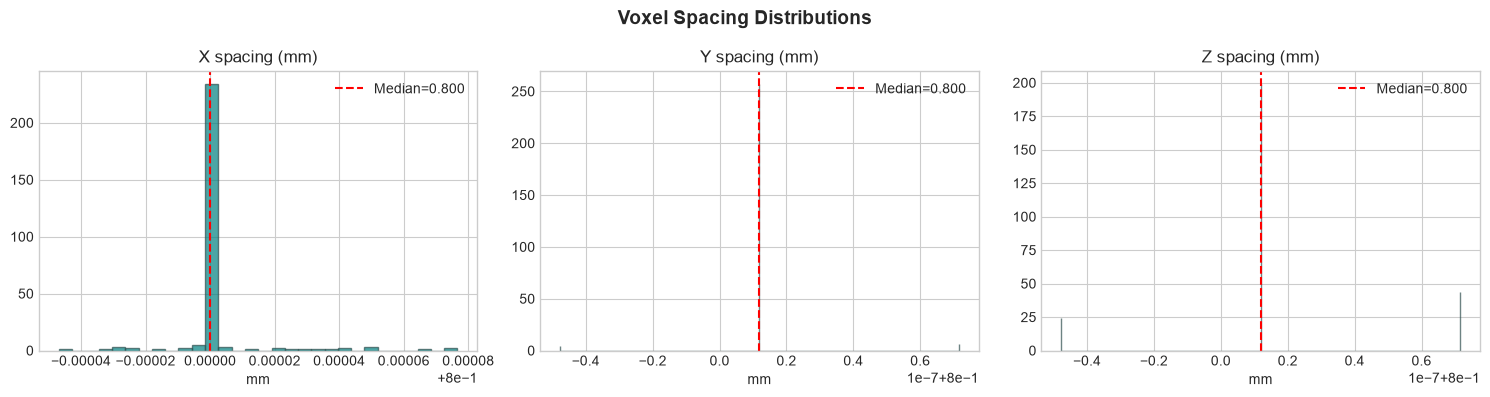


Orientation distribution:
orientation
LAS    267
Name: count, dtype: int64

→ Our preprocessing resamples all to spacing [1.0, 0.5, 0.5] mm and RAS orientation


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (col, label) in enumerate([
    ('spacing_x', 'X spacing (mm)'),
    ('spacing_y', 'Y spacing (mm)'),
    ('spacing_z', 'Z spacing (mm)'),
]):
    axes[i].hist(df_vol[col], bins=30, color='teal', alpha=0.7, edgecolor='darkslategray')
    axes[i].axvline(df_vol[col].median(), color='red', linestyle='--', 
                    label=f'Median={df_vol[col].median():.3f}')
    axes[i].set_title(label)
    axes[i].set_xlabel('mm')
    axes[i].legend()

plt.suptitle('Voxel Spacing Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nOrientation distribution:")
print(df_vol['orientation'].value_counts())
print(f"\n→ Our preprocessing resamples all to spacing [1.0, 0.5, 0.5] mm and RAS orientation")

## 3. Intensity Statistics

How do intensity distributions vary across sites? This informs our normalization strategy.

In [7]:
# Sample a subset of subjects for intensity statistics
# (Loading full volumes is slow, so we sample)

intensity_stats = []
sample_subjects = df_vol.sample(min(20, len(df_vol)), random_state=42) if len(df_vol) > 0 else df_vol

for _, row in sample_subjects.iterrows():
    sub_id = row['subject']
    img_path = DATA_ROOT / sub_id / "anat" / f"{sub_id}_T2w.nii.gz"
    
    try:
        data = np.asarray(nib.load(str(img_path)).dataobj).astype(np.float32)
        nonzero = data[data > 0]
        
        intensity_stats.append({
            "subject": sub_id,
            "site": row['site'],
            "mean": nonzero.mean(),
            "std": nonzero.std(),
            "median": np.median(nonzero),
            "p5": np.percentile(nonzero, 5),
            "p95": np.percentile(nonzero, 95),
            "max": nonzero.max(),
            "cv": nonzero.std() / nonzero.mean(),  # coefficient of variation
        })
    except Exception as e:
        print(f"  Error: {sub_id} — {e}")

df_intensity = pd.DataFrame(intensity_stats)
print(f"Computed intensity stats for {len(df_intensity)} subjects")
display(df_intensity.describe())

Computed intensity stats for 20 subjects


,mean,std,median,p5,p95,max,cv
count,20.000000,20.000000,20.000000,2.000000e+01,20.000000,2.000000e+01,20.000000
mean,33857.242188,42001.066406,20173.761719,1.446259e+02,106348.733954,3.518512e+05,1.377638
std,68829.679688,85624.562500,41904.867188,3.432570e+02,215875.074946,7.168733e+05,0.153211
min,138.719604,183.800385,57.000000,2.842171e-14,436.000000,1.791000e+03,1.026731
25%,310.565704,477.220253,120.250000,2.623016e+00,1231.500000,3.748250e+03,1.300403
50%,447.636627,668.027924,182.500000,4.000000e+00,1750.500000,4.095000e+03,1.377009
75%,550.464569,756.334579,254.500000,5.000000e+00,2138.750000,4.095000e+03,1.468359
max,179770.656250,231849.062500,123704.796875,1.006013e+03,584214.375000,1.866154e+06,1.651282


/tmp/ipykernel_3399917/2754064733.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_3399917/2754064733.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


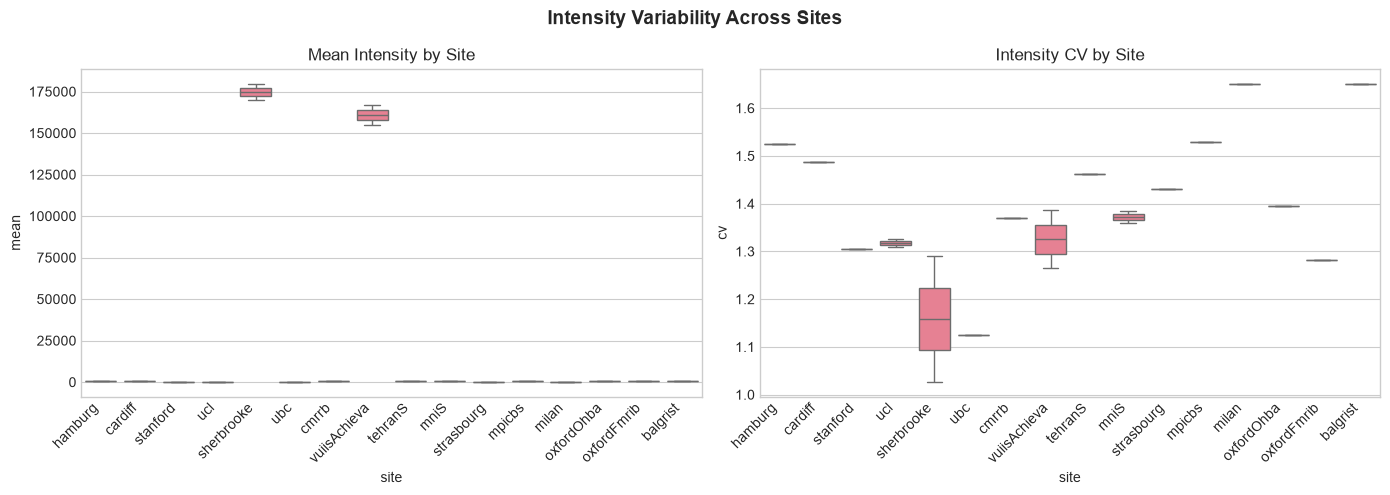


→ Large intensity variation across sites justifies per-volume nonzero normalization
  (NormalizeIntensityd with nonzero=True)


In [8]:
if len(df_intensity) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Mean intensity by site
    sns.boxplot(data=df_intensity, x='site', y='mean', ax=axes[0])
    axes[0].set_title('Mean Intensity by Site')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
    
    # Coefficient of variation
    sns.boxplot(data=df_intensity, x='site', y='cv', ax=axes[1])
    axes[1].set_title('Intensity CV by Site')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    
    plt.suptitle('Intensity Variability Across Sites', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n→ Large intensity variation across sites justifies per-volume nonzero normalization")
    print("  (NormalizeIntensityd with nonzero=True)")

## 4. Label Statistics & Class Imbalance

The spinal cord is a very small structure. Understanding the class imbalance is critical for training strategy.

In [9]:
# Check which subjects have real labels
label_stats = []

for sub_id in subject_dirs:
    lbl_path = LABELS_ROOT / sub_id / "anat" / f"{sub_id}_T2w_label-SC_seg.nii.gz"
    if not lbl_path.exists():
        continue
    
    file_size = lbl_path.stat().st_size
    is_real = file_size > 1000
    
    if is_real:
        try:
            lbl_nii = nib.load(str(lbl_path))
            lbl_data = np.asarray(lbl_nii.dataobj).astype(np.uint8)
            zooms = lbl_nii.header.get_zooms()[:3]
            voxel_vol_mm3 = float(np.prod(zooms))
            
            cord_voxels = (lbl_data > 0).sum()
            total_voxels = lbl_data.size
            cord_volume_mm3 = cord_voxels * voxel_vol_mm3
            
            # Find extent along each axis
            if cord_voxels > 0:
                coords = np.where(lbl_data > 0)
                extent_z = (coords[2].max() - coords[2].min()) * zooms[2]
            else:
                extent_z = 0
            
            try:
                site = get_site_from_subject(sub_id)
            except ValueError:
                site = "unknown"
            
            label_stats.append({
                "subject": sub_id,
                "site": site,
                "cord_voxels": cord_voxels,
                "total_voxels": total_voxels,
                "fraction_pct": 100 * cord_voxels / total_voxels,
                "cord_volume_mm3": cord_volume_mm3,
                "extent_z_mm": extent_z,
            })
        except Exception as e:
            pass

df_labels = pd.DataFrame(label_stats)

if len(df_labels) > 0:
    print(f"Subjects with real labels: {len(df_labels)}")
    print(f"\nClass imbalance (spinal cord as % of total volume):")
    print(f"  Mean:   {df_labels['fraction_pct'].mean():.4f}%")
    print(f"  Median: {df_labels['fraction_pct'].median():.4f}%")
    print(f"  Range:  [{df_labels['fraction_pct'].min():.4f}%, {df_labels['fraction_pct'].max():.4f}%]")
    print(f"\nCord volume (mm³):")
    print(f"  Mean:   {df_labels['cord_volume_mm3'].mean():.0f} mm³")
    print(f"  Median: {df_labels['cord_volume_mm3'].median():.0f} mm³")
    print(f"\n→ Extreme class imbalance (~0.1-0.5% foreground)!")
    print(f"  This is why we use RandCropByPosNegLabel with pos:neg = 2:1")
else:
    print("⚠️  No real labels found. Run: bash scripts/setup_data.sh")
    print("   Then re-run this cell.")

Subjects with real labels: 267

Class imbalance (spinal cord as % of total volume):
  Mean:   0.3743%
  Median: 0.3724%
  Range:  [0.2782%, 0.5140%]

Cord volume (mm³):
  Mean:   12296 mm³
  Median: 12148 mm³

→ Extreme class imbalance (~0.1-0.5% foreground)!
  This is why we use RandCropByPosNegLabel with pos:neg = 2:1


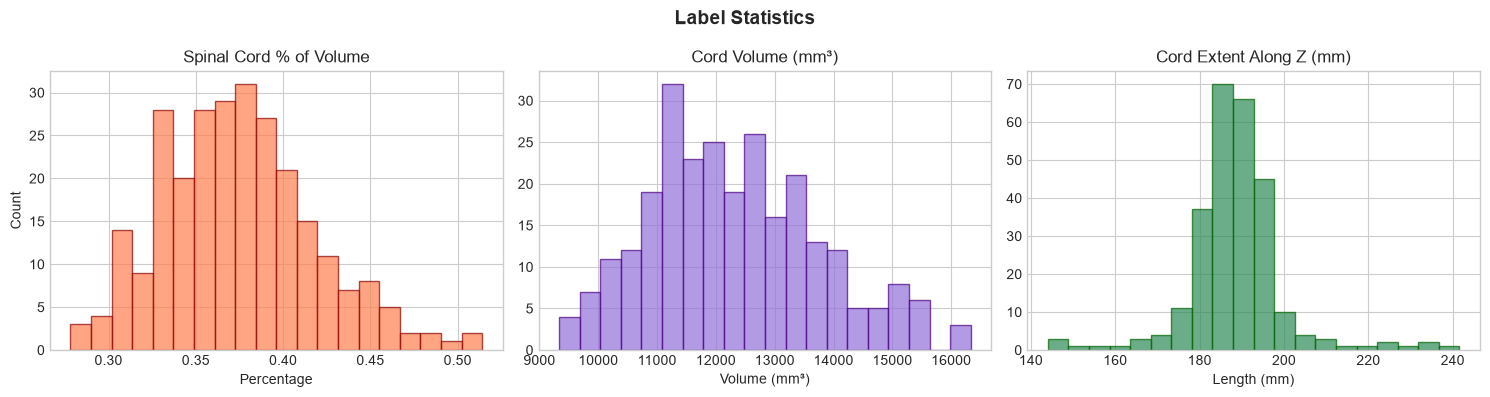

In [10]:
if len(df_labels) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    axes[0].hist(df_labels['fraction_pct'], bins=20, color='coral', edgecolor='darkred', alpha=0.7)
    axes[0].set_title('Spinal Cord % of Volume')
    axes[0].set_xlabel('Percentage')
    axes[0].set_ylabel('Count')
    
    axes[1].hist(df_labels['cord_volume_mm3'], bins=20, color='mediumpurple', edgecolor='indigo', alpha=0.7)
    axes[1].set_title('Cord Volume (mm³)')
    axes[1].set_xlabel('Volume (mm³)')
    
    axes[2].hist(df_labels['extent_z_mm'], bins=20, color='seagreen', edgecolor='darkgreen', alpha=0.7)
    axes[2].set_title('Cord Extent Along Z (mm)')
    axes[2].set_xlabel('Length (mm)')
    
    plt.suptitle('Label Statistics', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 5. Train/Validation Split

We split by **site** (not randomly) to prove cross-vendor generalization.
- **Validation sites:** stanford, tehranS, ubc, ucdavis, unf (diverse vendors)
- **Training:** everything else

In [11]:
import yaml

# Load config to get the official split
config_path = PROJECT_ROOT / "configs" / "train_spine.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

train_sites = config['data']['train_sites']
val_sites = config['data']['val_sites']

print(f"Train sites ({len(train_sites)}): {train_sites}")
print(f"Val sites ({len(val_sites)}):   {val_sites}")

# Map subjects to split
df_subjects['split'] = df_subjects['site'].apply(
    lambda s: 'train' if s in train_sites else ('val' if s in val_sites else 'excluded')
)

split_counts = df_subjects['split'].value_counts()
print(f"\nSplit distribution:")
print(split_counts)
print(f"\nTrain/Val ratio: {split_counts.get('train', 0)} / {split_counts.get('val', 0)}")

Train sites (23): ['amu', 'balgrist', 'barcelona', 'beijing', 'brno', 'cardiff', 'chiba', 'cmrra', 'douglas', 'geneva', 'juntendo', 'hamburg', 'mgh', 'mountsinai', 'nottingham', 'oxford', 'pavia', 'perform', 'sherbrooke', 'strasbourg', 'tokyo', 'ucl', 'vuiis']
Val sites (5):   ['stanford', 'tehranS', 'ubc', 'ucdavis', 'unf']

Split distribution:
split
excluded    157
train        78
val          32
Name: count, dtype: int64

Train/Val ratio: 78 / 32


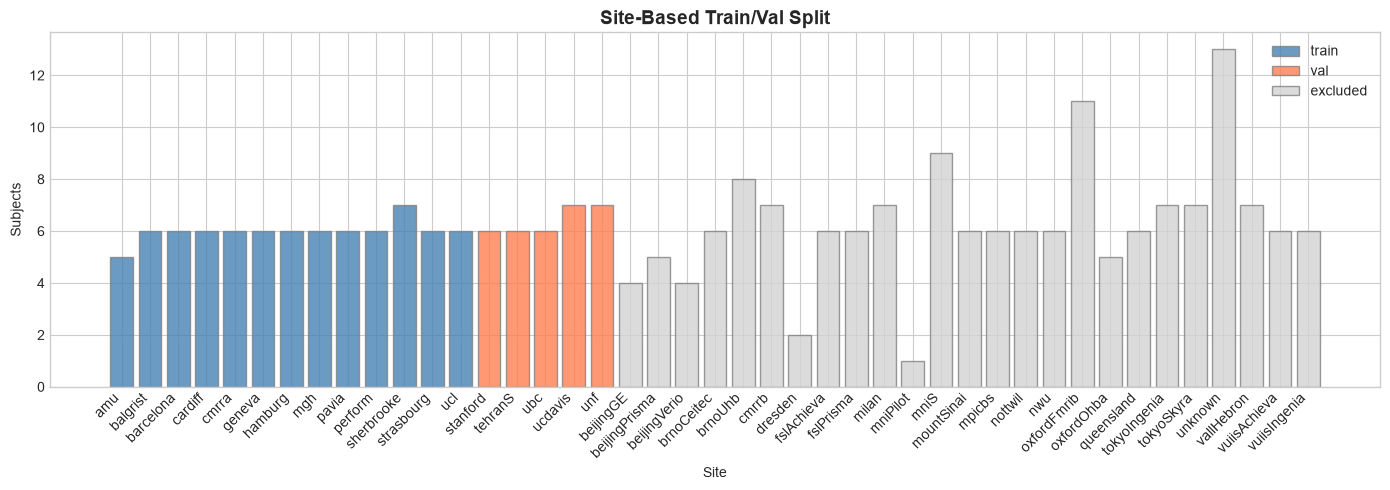

In [12]:
# Visualize the split
split_by_site = df_subjects.groupby(['site', 'split']).size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(14, 5))

colors = {'train': 'steelblue', 'val': 'coral', 'excluded': 'lightgray'}

for split_name in ['train', 'val', 'excluded']:
    subset = split_by_site[split_by_site['split'] == split_name]
    if not subset.empty:
        ax.bar(subset['site'], subset['count'], color=colors[split_name], 
               label=split_name, alpha=0.8, edgecolor='gray')

ax.set_title('Site-Based Train/Val Split', fontsize=14, fontweight='bold')
ax.set_xlabel('Site')
ax.set_ylabel('Subjects')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Data Quality Check with our Data Loader

Let's test our actual `create_datalist` function to see what it finds.

In [13]:
# Test our actual data loader
train_data = create_datalist(root_dir=DATA_ROOT, sites=train_sites)
val_data = create_datalist(root_dir=DATA_ROOT, sites=val_sites)

print(f"\ncreate_datalist results:")
print(f"  Training:   {len(train_data)} image/label pairs")
print(f"  Validation: {len(val_data)} image/label pairs")

if len(train_data) > 0:
    print(f"\nSample entry:")
    for k, v in train_data[0].items():
        print(f"  {k}: {v}")
else:
    print("\n⚠️  No data pairs found!")
    print("   Likely cause: label files are git-annex stubs.")
    print("   Fix: bash scripts/setup_data.sh")

Skipping subject with unparseable ID: sub-juntendo750w01
Skipping subject with unparseable ID: sub-juntendo750w02
Skipping subject with unparseable ID: sub-juntendo750w03
Skipping subject with unparseable ID: sub-juntendo750w04
Skipping subject with unparseable ID: sub-juntendo750w05
Skipping subject with unparseable ID: sub-juntendo750w06
Skipping subject with unparseable ID: sub-tokyo750w01
Skipping subject with unparseable ID: sub-tokyo750w02
Skipping subject with unparseable ID: sub-tokyo750w03
Skipping subject with unparseable ID: sub-tokyo750w04
Skipping subject with unparseable ID: sub-tokyo750w05
Skipping subject with unparseable ID: sub-tokyo750w06
Skipping subject with unparseable ID: sub-tokyo750w07
Skipping subject with unparseable ID: sub-juntendo750w01
Skipping subject with unparseable ID: sub-juntendo750w02
Skipping subject with unparseable ID: sub-juntendo750w03
Skipping subject with unparseable ID: sub-juntendo750w04
Skipping subject with unparseable ID: sub-juntendo75


create_datalist results:
  Training:   78 image/label pairs
  Validation: 32 image/label pairs

Sample entry:
  image: ../data/spine-generic/sub-amu01/anat/sub-amu01_T2w.nii.gz
  label: ../data/spine-generic/derivatives/labels/sub-amu01/anat/sub-amu01_T2w_label-SC_seg.nii.gz
  subject: sub-amu01
  site: amu


## Summary & Key Findings

| Property | Value | Implication |
|----------|-------|-------------|
| Subjects | ~267 | Good dataset size for medical imaging |
| Sites | 42 | Excellent vendor diversity |
| Voxel spacing | Highly variable | Must resample to [1.0, 0.5, 0.5] |
| Orientations | Mixed | Must reorient to RAS |
| Intensity range | Varies wildly across sites | Nonzero normalization essential |
| Class imbalance | ~0.1-0.5% foreground | Patch-based training with pos/neg sampling |
| Cord extent | ~80-200mm along Z | Patch size [48,160,160] covers cross-section |

**Next:** → Notebook 3 for preprocessing transforms visualization